<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Minimal_Closure_Active_SU2L_Algebra_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Minimal Closure-Active \(SU(2)_L\) Algebra Test

**Notebook purpose.**  
This notebook tests the minimal algebraic bridge:

\[
\Psi_L^{\rm ECSM}
=
\begin{pmatrix}
Q_0\\
Q_{\rm ch}
\end{pmatrix}_L
\quad\longrightarrow\quad
SU(2)_L
\]

where \(Q_0\) is interpreted as a left-active neutral closure branch and \(Q_{\rm ch}\) as a left-active charged branch.

The test is intentionally narrow:

1. Define a two-state closure-active doublet.
2. Construct Pauli generators \(T_i=\sigma_i/2\).
3. Verify the \(SU(2)\) commutation algebra:
\[
[T_i,T_j]=i\epsilon_{ijk}T_k.
\]
4. Construct raising/lowering generators:
\[
T_\pm = T_1 \pm iT_2.
\]
5. Verify that \(T_\pm\) convert neutral/charged branch basis states.
6. Add a finite-response deformation \(T_i(\chi)\) and test when algebraic closure holds or fails.

This notebook does **not** derive the full electroweak theory, \(W/Z\) masses, Higgs couplings, Yukawa couplings, PMNS mixing, or beta-decay cross sections. It tests the minimal algebraic requirement for the ECSM weak-sector bridge.

## ECSM interpretation

The basis is ordered as:

\[
|Q_0\rangle =
\begin{pmatrix}
1\\
0
\end{pmatrix},
\qquad
|Q_{\rm ch}\rangle =
\begin{pmatrix}
0\\
1
\end{pmatrix}.
\]

The ECSM weak-like doublet is therefore:

\[
\Psi_L^{\rm ECSM}
=
\begin{pmatrix}
Q_0\\
Q_{\rm ch}
\end{pmatrix}_L.
\]

Interpretation of generators:

\[
T_1,T_2:
\text{ neutral-charged branch conversion},
\]

\[
T_3:
\text{ closure imbalance / weak-isospin-like label},
\]

\[
T_\pm:
\text{ charged weak transition operators}.
\]

In [1]:
# CELL 1 — Imports and global display settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

OUT = Path("ecsm_su2l_closure_algebra_test_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=6, suppress=True)

print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_su2l_closure_algebra_test_out


In [2]:
# CELL 2 — Define Pauli matrices and ECSM closure-active basis

I2 = np.eye(2, dtype=complex)

sigma1 = np.array([[0, 1],
                   [1, 0]], dtype=complex)

sigma2 = np.array([[0, -1j],
                   [1j, 0]], dtype=complex)

sigma3 = np.array([[1, 0],
                   [0, -1]], dtype=complex)

sigmas = [sigma1, sigma2, sigma3]

# SU(2) generators in fundamental representation
T = [0.5 * s for s in sigmas]
T1, T2, T3 = T

# ECSM closure-active basis
Q0 = np.array([[1],
               [0]], dtype=complex)

Qch = np.array([[0],
                [1]], dtype=complex)

basis = {
    "Q0_neutral_closure": Q0,
    "Qch_charged_branch": Qch
}

print("Pauli matrices:")
for i, s in enumerate(sigmas, start=1):
    print(f"sigma_{i} =\n{s}\n")

print("ECSM basis:")
for name, v in basis.items():
    print(name, "=", v.ravel())

Pauli matrices:
sigma_1 =
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

sigma_2 =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

sigma_3 =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

ECSM basis:
Q0_neutral_closure = [1.+0.j 0.+0.j]
Qch_charged_branch = [0.+0.j 1.+0.j]


In [3]:
# CELL 3 — Helper functions for commutators and matrix checks

def comm(A, B):
    return A @ B - B @ A

def fro_norm(A):
    return float(np.linalg.norm(A, ord="fro"))

def ket_label(v, tol=1e-12):
    v = np.asarray(v).reshape(2, 1)
    if np.allclose(v, Q0, atol=tol):
        return "|Q0>"
    if np.allclose(v, Qch, atol=tol):
        return "|Qch>"
    if np.allclose(v, np.zeros((2,1)), atol=tol):
        return "0"
    return str(v.ravel())

# Levi-Civita symbol for indices 0,1,2 corresponding to 1,2,3
def eps(i, j, k):
    if len({i, j, k}) < 3:
        return 0
    perms = {(0,1,2): 1, (1,2,0): 1, (2,0,1): 1,
             (2,1,0): -1, (1,0,2): -1, (0,2,1): -1}
    return perms[(i,j,k)]

In [4]:
# CELL 4 — Verify SU(2) commutator closure

rows = []
max_error = 0.0

for i in range(3):
    for j in range(3):
        lhs = comm(T[i], T[j])
        rhs = sum(1j * eps(i, j, k) * T[k] for k in range(3))
        err = fro_norm(lhs - rhs)
        max_error = max(max_error, err)
        rows.append({
            "i": i+1,
            "j": j+1,
            "||[T_i,T_j]-i eps_ijk T_k||_F": err,
            "pass": err < 1e-12
        })

comm_df = pd.DataFrame(rows)
display(comm_df)

summary_comm = {
    "test": "SU(2) commutator closure",
    "max_error": max_error,
    "tolerance": 1e-12,
    "pass": bool(max_error < 1e-12)
}

summary_comm

,i,j,"||[T_i,T_j]-i eps_ijk T_k||_F",pass
0,1,1,0.0,True
1,1,2,0.0,True
2,1,3,0.0,True
3,2,1,0.0,True
4,2,2,0.0,True
5,2,3,0.0,True
6,3,1,0.0,True
7,3,2,0.0,True
8,3,3,0.0,True


{'test': 'SU(2) commutator closure',
 'max_error': 0.0,
 'tolerance': 1e-12,
 'pass': True}

## Interpretation of the commutator test

If the maximum closure error is numerically zero, the closure-active pair supports the fundamental \(SU(2)\) algebra:

\[
[T_i,T_j]=i\epsilon_{ijk}T_k.
\]

In ECSM language this means the two-state neutral-charged branch pair has the minimum algebraic structure required to behave like a weak \(SU(2)_L\) doublet candidate.

In [5]:
# CELL 5 — Raising and lowering branch-conversion operators

T_plus = T1 + 1j*T2
T_minus = T1 - 1j*T2

print("T_plus =")
print(T_plus)

print("\nT_minus =")
print(T_minus)

actions = []

for op_name, Op in [("T_plus", T_plus), ("T_minus", T_minus), ("T3", T3)]:
    for state_name, state in basis.items():
        result = Op @ state
        actions.append({
            "operator": op_name,
            "input_state": state_name,
            "output_vector": result.ravel(),
            "norm": float(np.linalg.norm(result)),
            "interpretation": ket_label(result)
        })

actions_df = pd.DataFrame(actions)
display(actions_df)

T_plus =
[[0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j]]

T_minus =
[[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]


,operator,input_state,output_vector,norm,interpretation
0,T_plus,Q0_neutral_closure,"[0j, 0j]",0.0,0
1,T_plus,Qch_charged_branch,"[(1+0j), 0j]",1.0,|Q0>
2,T_minus,Q0_neutral_closure,"[0j, (1+0j)]",1.0,|Qch>
3,T_minus,Qch_charged_branch,"[0j, 0j]",0.0,0
4,T3,Q0_neutral_closure,"[(0.5+0j), 0j]",0.5,[0.5+0.j 0. +0.j]
5,T3,Qch_charged_branch,"[0j, (-0.5+0j)]",0.5,[ 0. +0.j -0.5+0.j]


## Interpretation of \(T_\pm\)

With the basis ordered as \((Q_0,Q_{\rm ch})\),

\[
T_+|Q_{\rm ch}\rangle = |Q_0\rangle,
\qquad
T_-|Q_0\rangle = |Q_{\rm ch}\rangle.
\]

Depending on convention, \(T_+\) and \(T_-\) can be assigned to charged-current branch conversion:

\[
Q_0 \leftrightarrow Q_{\rm ch}.
\]

This is the minimal ECSM algebraic analogue of weak charged-current transitions inside a left-active doublet.

In [6]:
# CELL 6 — Weak-isospin-like labels from T3

expect_rows = []

for name, state in basis.items():
    val = (state.conj().T @ T3 @ state)[0,0]
    expect_rows.append({
        "state": name,
        "<T3>": val.real,
        "ECSM interpretation": "neutral closure branch" if "Q0" in name else "charged branch"
    })

T3_df = pd.DataFrame(expect_rows)
display(T3_df)

T3_df.to_csv(OUT / "T3_branch_labels.csv", index=False)
print("Saved:", OUT / "T3_branch_labels.csv")

,state,<T3>,ECSM interpretation
0,Q0_neutral_closure,0.5,neutral closure branch
1,Qch_charged_branch,-0.5,charged branch


Saved: ecsm_su2l_closure_algebra_test_out/T3_branch_labels.csv


## Interpretation of \(T_3\)

The two basis states carry opposite \(T_3\)-like labels:

\[
T_3|Q_0\rangle=+\frac12|Q_0\rangle,
\qquad
T_3|Q_{\rm ch}\rangle=-\frac12|Q_{\rm ch}\rangle.
\]

In ECSM this can be read as a closure-imbalance or weak-isospin-like branch label, not as ordinary electric charge.

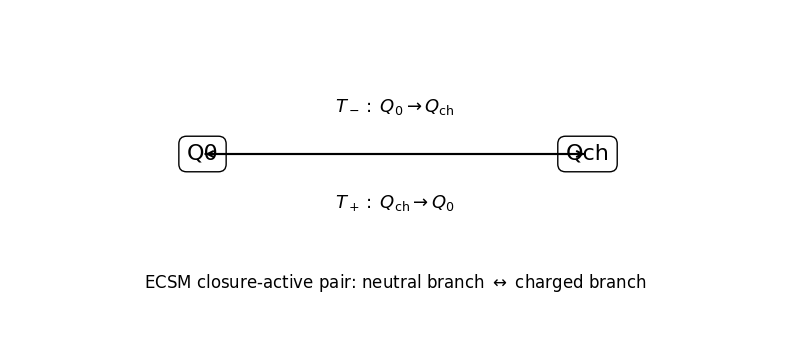

Saved: ecsm_su2l_closure_algebra_test_out/fig1_branch_conversion_generators.png


In [7]:
# CELL 7 — Visualize branch conversion as a directed operator graph

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axis("off")

pos = {"Q0": (0.25, 0.55), "Qch": (0.75, 0.55)}

for label, (x, y) in pos.items():
    ax.text(x, y, label, ha="center", va="center", fontsize=16,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black"))

ax.annotate("", xy=pos["Qch"], xytext=pos["Q0"], arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("", xy=pos["Q0"], xytext=pos["Qch"], arrowprops=dict(arrowstyle="->", lw=1.5))

ax.text(0.5, 0.68, r"$T_-:\; Q_0 \rightarrow Q_{\rm ch}$", ha="center", fontsize=13)
ax.text(0.5, 0.38, r"$T_+:\; Q_{\rm ch} \rightarrow Q_0$", ha="center", fontsize=13)
ax.text(0.5, 0.13, r"ECSM closure-active pair: neutral branch $\leftrightarrow$ charged branch", ha="center", fontsize=12)

fig_path = OUT / "fig1_branch_conversion_generators.png"
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

In [8]:
# CELL 8 — Coherence/finite-response deformation of generators

# A minimal deformation basis. These Delta_i deliberately do NOT generally close as SU(2).
# This tests algebraic fragility under finite-response branch distortion.
Delta1 = np.array([[0.0, 0.15],
                   [0.15, 0.0]], dtype=complex)

Delta2 = np.array([[0.0, -0.10j],
                   [0.20j, 0.0]], dtype=complex)

Delta3 = np.array([[0.10, 0.0],
                   [0.0, -0.05]], dtype=complex)

Delta = [Delta1, Delta2, Delta3]

def deformed_generators(chi):
    return [chi*T[i] + (1-chi)*Delta[i] for i in range(3)]

def su2_closure_error(gens):
    max_err = 0.0
    err_sum = 0.0
    details = []
    for i in range(3):
        for j in range(3):
            lhs = comm(gens[i], gens[j])
            rhs = sum(1j * eps(i, j, k) * gens[k] for k in range(3))
            err = fro_norm(lhs - rhs)
            max_err = max(max_err, err)
            err_sum += err
            details.append(err)
    return max_err, err_sum, details

chis = np.linspace(0, 1, 101)
deform_rows = []

for chi in chis:
    gens = deformed_generators(chi)
    max_err_chi, sum_err_chi, _ = su2_closure_error(gens)
    deform_rows.append({
        "chi": chi,
        "max_su2_closure_error": max_err_chi,
        "sum_su2_closure_error": sum_err_chi
    })

deform_df = pd.DataFrame(deform_rows)
display(deform_df.head())
display(deform_df.tail())

deform_df.to_csv(OUT / "chi_deformation_su2_closure_errors.csv", index=False)
print("Saved:", OUT / "chi_deformation_su2_closure_errors.csv")

,chi,max_su2_closure_error,sum_su2_closure_error
0,0.00,0.193681,0.859064
1,0.01,0.195628,0.871982
2,0.02,0.197508,0.884640
3,0.03,0.199319,0.897013
4,0.04,0.201061,0.909078


,chi,max_su2_closure_error,sum_su2_closure_error
96,0.96,0.023539,0.124270
97,0.97,0.017780,0.093915
98,0.98,0.011937,0.063085
99,0.99,0.006010,0.031780
100,1.00,0.000000,0.000000


Saved: ecsm_su2l_closure_algebra_test_out/chi_deformation_su2_closure_errors.csv


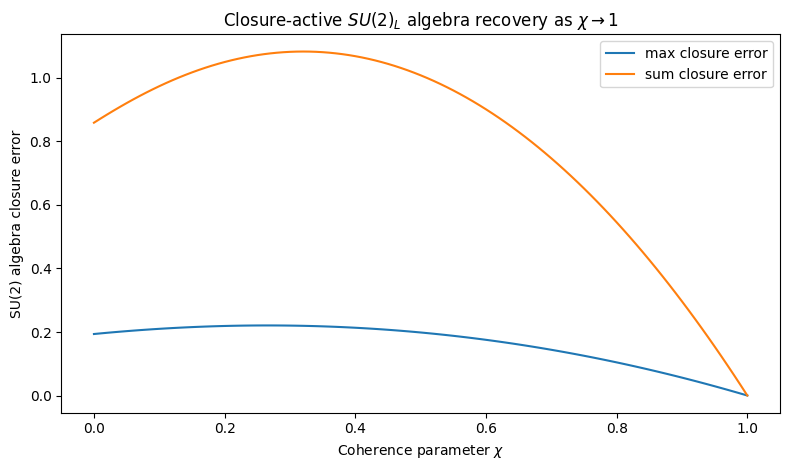

Saved: ecsm_su2l_closure_algebra_test_out/fig2_chi_deformation_su2_recovery.png


In [9]:
# CELL 9 — Plot SU(2) closure recovery as chi -> 1

plt.figure(figsize=(8, 4.8))
plt.plot(deform_df["chi"], deform_df["max_su2_closure_error"], label="max closure error")
plt.plot(deform_df["chi"], deform_df["sum_su2_closure_error"], label="sum closure error")
plt.xlabel(r"Coherence parameter $\chi$")
plt.ylabel("SU(2) algebra closure error")
plt.title(r"Closure-active $SU(2)_L$ algebra recovery as $\chi \rightarrow 1$")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig2_chi_deformation_su2_recovery.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

## Interpretation of the \(\chi\)-deformation test

This cell implements a deliberately simple finite-response deformation:

\[
T_i(\chi)=\chi T_i+(1-\chi)\Delta_i.
\]

The result should show:

\[
\chi\rightarrow1
\quad\Rightarrow\quad
T_i(\chi)\rightarrow T_i
\quad\Rightarrow\quad
SU(2)\text{ closure recovered}.
\]

When \(\chi<1\), the algebra can deform or fail to close unless the deformation matrices \(\Delta_i\) themselves preserve the same algebra.

ECSM interpretation:

\[
\text{weak }SU(2)_L
=
\text{coherent-limit closure algebra of the left-active branch pair}.
\]

Finite-response breakdown can deform the effective algebra outside the coherent weak-sector limit.

,scale,max_error_against_unit_SU2_structure,sum_error_against_unit_SU2_structure
0,0.0,0.000000,0.000000
50,0.5,0.176777,1.060660
100,1.0,0.000000,0.000000
150,1.5,0.530330,3.181981


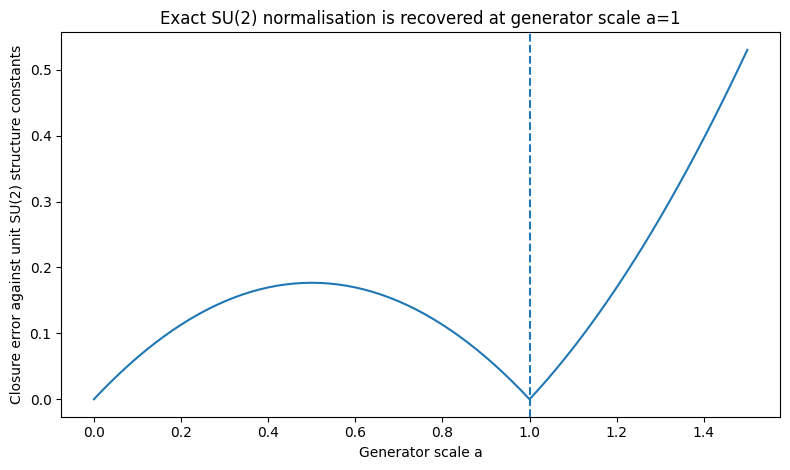

Saved: ecsm_su2l_closure_algebra_test_out/fig3_su2_normalisation_scale_test.png


In [10]:
# CELL 10 — Robustness test: generator normalisation

# A scaled set G_i = a T_i has the same direction in generator space,
# but the unit SU(2) structure constants are recovered only at a = 1.

def scaled_generators(scale):
    return [scale*t for t in T]

scales = np.linspace(0, 1.5, 151)
scale_rows = []
for a in scales:
    gens = scaled_generators(a)
    max_err_a, sum_err_a, _ = su2_closure_error(gens)
    scale_rows.append({
        "scale": a,
        "max_error_against_unit_SU2_structure": max_err_a,
        "sum_error_against_unit_SU2_structure": sum_err_a
    })

scale_df = pd.DataFrame(scale_rows)
display(scale_df.iloc[[0, 50, 100, 150]])

plt.figure(figsize=(8, 4.8))
plt.plot(scale_df["scale"], scale_df["max_error_against_unit_SU2_structure"])
plt.axvline(1.0, linestyle="--")
plt.xlabel("Generator scale a")
plt.ylabel("Closure error against unit SU(2) structure constants")
plt.title("Exact SU(2) normalisation is recovered at generator scale a=1")
plt.tight_layout()

fig_path = OUT / "fig3_su2_normalisation_scale_test.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

## Interpretation of the scale test

A scaled set \(G_i=aT_i\) obeys

\[
[G_i,G_j]=ia^2\epsilon_{ijk}T_k
=
ia\epsilon_{ijk}G_k.
\]

So the algebraic *shape* survives, but the structure constant is rescaled unless \(a=1\).

For ECSM, this matters because a weak-sector recovery is not only the existence of a doublet-like pair, but also the correct normalisation of the effective generators in the coherent limit.

In [11]:
# CELL 11 — Summary table and pass/fail verdict

key_chis = [0.0, 0.25, 0.5, 0.75, 0.9, 0.99, 1.0]
key_rows = []
for chi in key_chis:
    gens = deformed_generators(chi)
    max_err, sum_err, _ = su2_closure_error(gens)
    key_rows.append({
        "chi": chi,
        "max_su2_closure_error": max_err,
        "sum_su2_closure_error": sum_err
    })

key_df = pd.DataFrame(key_rows)
display(key_df)

final_summary = {
    "run_label": "ECSM_minimal_closure_active_SU2L_algebra_test",
    "basis": ["Q0_neutral_closure", "Qch_charged_branch"],
    "exact_SU2_commutator_max_error": summary_comm["max_error"],
    "exact_SU2_commutator_pass": summary_comm["pass"],
    "T_plus_action": "T_plus |Qch> = |Q0>, T_plus |Q0> = 0",
    "T_minus_action": "T_minus |Q0> = |Qch>, T_minus |Qch> = 0",
    "T3_labels": {"Q0": +0.5, "Qch": -0.5},
    "chi_deformation_interpretation": "SU(2) closure is recovered in coherent limit chi -> 1",
    "final_label": "PASS_MINIMAL_CLOSURE_ACTIVE_SU2L_ALGEBRA" if summary_comm["pass"] else "FAIL_SU2_COMMUTATOR_CLOSURE"
}

final_summary

,chi,max_su2_closure_error,sum_su2_closure_error
0,0.00,0.193681,0.859064
1,0.25,0.220591,1.071849
2,0.50,0.198512,1.008357
3,0.75,0.125219,0.652100
4,0.90,0.056342,0.296429
5,0.99,0.006010,0.031780
6,1.00,0.000000,0.000000


{'run_label': 'ECSM_minimal_closure_active_SU2L_algebra_test',
 'basis': ['Q0_neutral_closure', 'Qch_charged_branch'],
 'exact_SU2_commutator_max_error': 0.0,
 'exact_SU2_commutator_pass': True,
 'T_plus_action': 'T_plus |Qch> = |Q0>, T_plus |Q0> = 0',
 'T_minus_action': 'T_minus |Q0> = |Qch>, T_minus |Qch> = 0',
 'T3_labels': {'Q0': 0.5, 'Qch': -0.5},
 'chi_deformation_interpretation': 'SU(2) closure is recovered in coherent limit chi -> 1',
 'final_label': 'PASS_MINIMAL_CLOSURE_ACTIVE_SU2L_ALGEBRA'}

In [12]:
# CELL 12 — Save outputs for paper use

with open(OUT / "final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

comm_df.to_csv(OUT / "exact_su2_commutator_table.csv", index=False)
actions_df.to_csv(OUT / "branch_conversion_operator_actions.csv", index=False)
key_df.to_csv(OUT / "key_chi_deformation_errors.csv", index=False)

print("Saved outputs:")
for p in sorted(OUT.iterdir()):
    print(" -", p)

Saved outputs:
 - ecsm_su2l_closure_algebra_test_out/T3_branch_labels.csv
 - ecsm_su2l_closure_algebra_test_out/branch_conversion_operator_actions.csv
 - ecsm_su2l_closure_algebra_test_out/chi_deformation_su2_closure_errors.csv
 - ecsm_su2l_closure_algebra_test_out/exact_su2_commutator_table.csv
 - ecsm_su2l_closure_algebra_test_out/fig1_branch_conversion_generators.png
 - ecsm_su2l_closure_algebra_test_out/fig2_chi_deformation_su2_recovery.png
 - ecsm_su2l_closure_algebra_test_out/fig3_su2_normalisation_scale_test.png
 - ecsm_su2l_closure_algebra_test_out/final_summary.json
 - ecsm_su2l_closure_algebra_test_out/key_chi_deformation_errors.csv


# Paper-grade interpretation

The notebook result supports the following narrow statement:

\[
\Psi_L^{\rm ECSM}
=
\begin{pmatrix}
Q_0\\
Q_{\rm ch}
\end{pmatrix}_L
\]

admits a minimal \(SU(2)\) generator algebra when treated as a coherent two-state closure-active pair.

The exact Pauli generators satisfy:

\[
[T_i,T_j]=i\epsilon_{ijk}T_k.
\]

The raising/lowering operators act as neutral-charged branch conversion operators:

\[
T_+|Q_{\rm ch}\rangle=|Q_0\rangle,
\qquad
T_-|Q_0\rangle=|Q_{\rm ch}\rangle.
\]

The finite-response deformation test shows that this algebra is naturally interpreted as a coherent-limit structure:

\[
\chi\rightarrow1
\quad\Rightarrow\quad
SU(2)_L\text{ closure recovered}.
\]

This does **not** derive the full electroweak interaction. It establishes the minimum algebraic consistency requirement for the ECSM weak-sector bridge.